HELDOUT METRICS  (first-heldout, n_seeds=100)

Accuracy
  Flat : 0.5025 ± 0.0544 (95% CI half-width)
  Hier : 0.6800 ± 0.0406
  Advantage (Hier−Flat): +0.1775 ± 0.0688
  t(99) = +5.117, p = 0.0000, d = 0.512

Signed shape contrast
  Flat : 0.0023 ± 0.0012 (95% CI half-width)
  Hier : 0.0203 ± 0.0026
  Advantage (Hier−Flat): +0.0180 ± 0.0029
  t(99) = +12.503, p = 0.0000, d = 1.250

Signed prediction margin
  Flat : 0.0011 ± 0.0006 (95% CI half-width)
  Hier : 0.0102 ± 0.0013
  Advantage (Hier−Flat): +0.0090 ± 0.0014
  t(99) = +12.503, p = 0.0000, d = 1.250

Brier score
  Flat : 0.2489 ± 0.0006 (95% CI half-width)
  Hier : 0.2403 ± 0.0012
  Reduction (Flat−Hier): +0.0086 ± 0.0014
  t(99) = +12.486, p = 0.0000, d = 1.249

Log loss
  Flat : 0.6909 ± 0.0012 (95% CI half-width)
  Hier : 0.6737 ± 0.0025
  Reduction (Flat−Hier): +0.0172 ± 0.0027
  t(99) = +12.478, p = 0.0000, d = 1.248


Text(0.5, 1.01, 'Shape × Many Colors Transfer  |  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]  |  train_colors=8  test_colors=2')

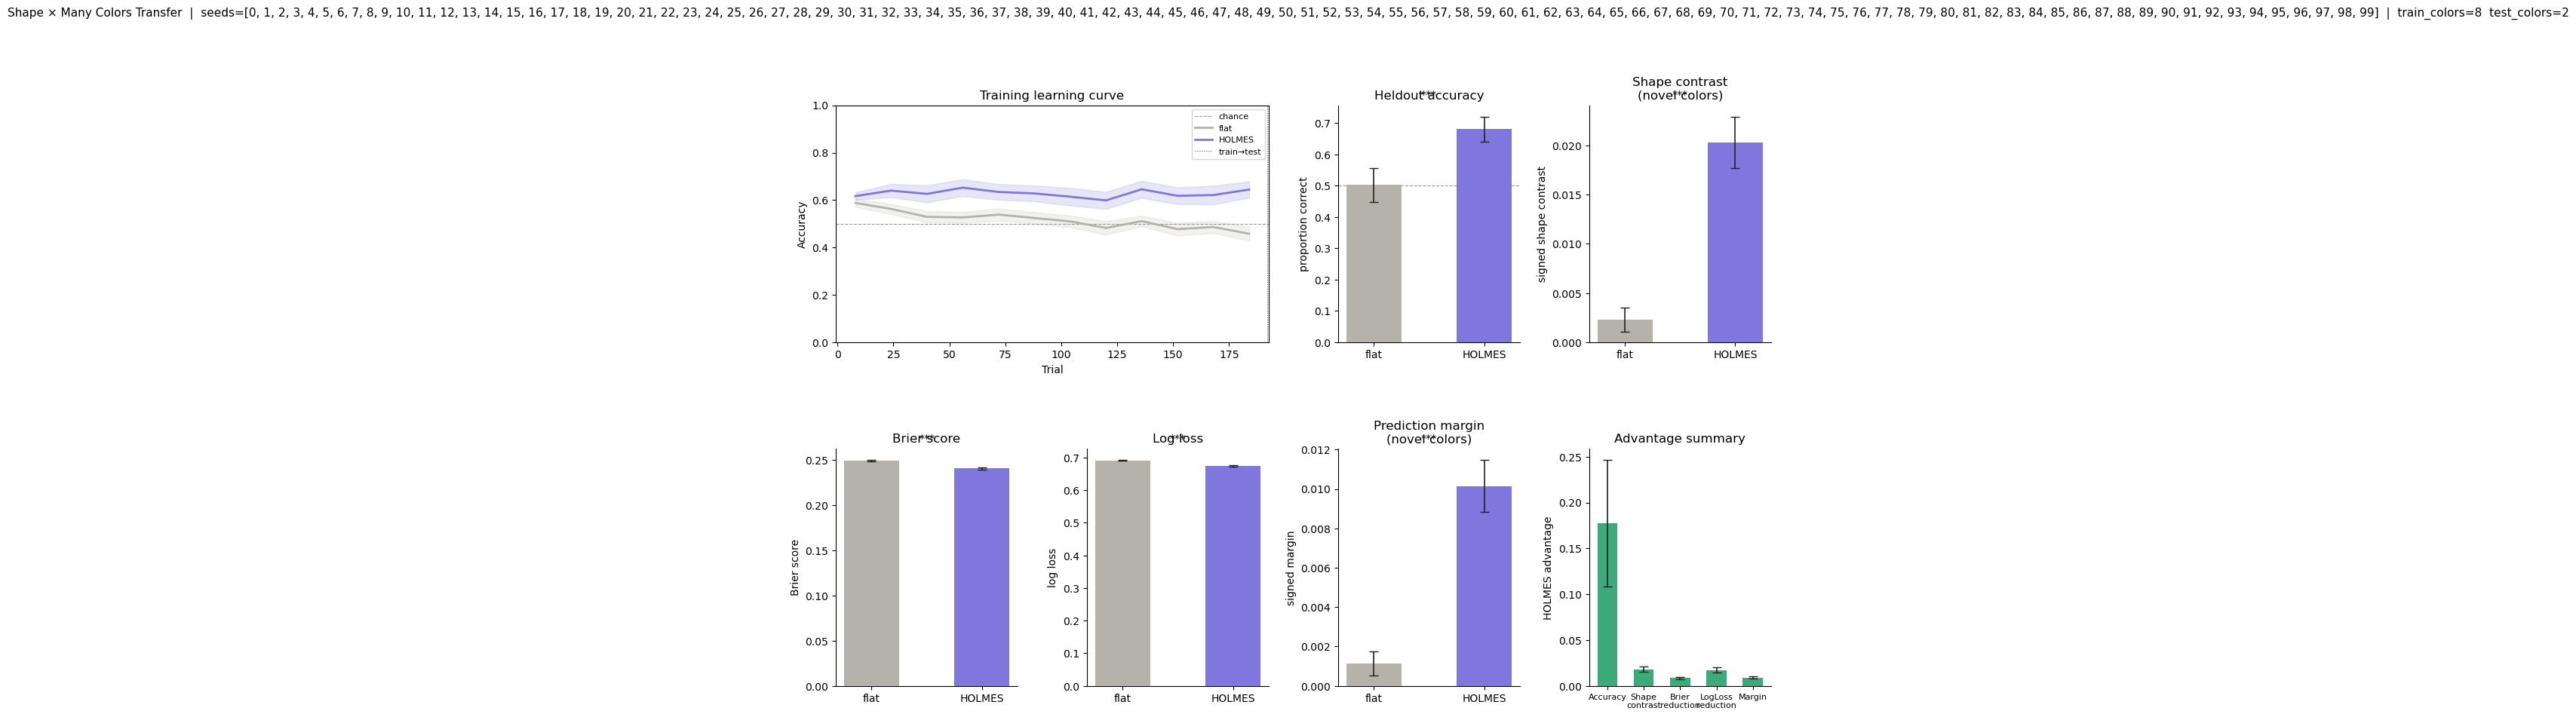

In [2]:
# ============================================================
# Shape × Many Colors Transfer Task — Analysis & Plots
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# ── load ─────────────────────────────────────────────────────
df = pd.read_csv("shape_color_transfer_20260603_115258_all_trials.csv")

# Convenience booleans
train = df["phase"] == "train"
test  = df["phase"] == "test"
held  = df["is_first_heldout"].astype(bool)

# ── palette ──────────────────────────────────────────────────
C_FLAT = "#B4B2A9"
C_HIER = "#7F77DD"
C_ADV  = "#3DAA7A"
ALPHA_ERR = 0.18

# ── helper: mean ± 95% CI across seeds ───────────────────────
def ci95(series_by_seed):
    """
    series_by_seed: array-like of per-seed means.
    Returns (mean, lower_err, upper_err) where errors are
    half-widths of the 95% CI (t-distribution).
    """
    vals = np.asarray(series_by_seed, dtype=float)
    vals = vals[np.isfinite(vals)]
    n    = len(vals)
    if n < 2:
        return float(vals.mean()) if n == 1 else np.nan, np.nan, np.nan
    m    = vals.mean()
    se   = stats.sem(vals)
    h    = se * stats.t.ppf(0.975, df=n - 1)
    return m, h, h          # symmetric CI

def ttest(vals, null=0.0):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) < 2:
        return np.nan, np.nan
    t, p = stats.ttest_1samp(vals, null)
    return t, p

# ============================================================
# 1. LEARNING CURVE  (training trials only)
#    Bin training trials into windows; compute per-seed
#    accuracy in each bin; then average across seeds.
# ============================================================

BIN_SIZE = 16   # trials per bin — adjust to taste

train_df = df[train].copy()
train_df["bin"] = (train_df["trial"] // BIN_SIZE) * BIN_SIZE

seeds       = sorted(df["seed"].unique())
bin_centers = sorted(train_df["bin"].unique())

flat_curve_seeds = []   # shape: (n_seeds, n_bins)
hier_curve_seeds = []

for seed in seeds:
    s = train_df[train_df["seed"] == seed]
    flat_row, hier_row = [], []
    for b in bin_centers:
        bdata = s[s["bin"] == b]
        flat_row.append(bdata["flat_correct"].mean())
        hier_row.append(bdata["hier_correct"].mean())
    flat_curve_seeds.append(flat_row)
    hier_curve_seeds.append(hier_row)

flat_curve_seeds = np.array(flat_curve_seeds)   # (seeds, bins)
hier_curve_seeds = np.array(hier_curve_seeds)

# Mean and CI across seeds at each bin
flat_mean  = flat_curve_seeds.mean(axis=0)
hier_mean  = hier_curve_seeds.mean(axis=0)
n_seeds    = len(seeds)

def curve_ci(arr):
    """arr shape: (seeds, bins) → (bins,) CI half-widths"""
    se = arr.std(axis=0, ddof=1) / np.sqrt(n_seeds)
    h  = se * stats.t.ppf(0.975, df=n_seeds - 1)
    return h

flat_ci = curve_ci(flat_curve_seeds)
hier_ci = curve_ci(hier_curve_seeds)

# ============================================================
# 2. HELDOUT METRICS  (first-heldout test trials)
# ============================================================

held_df = df[held].copy()

# Per-seed aggregates
def per_seed_metric(col_flat, col_hier, agg="mean"):
    rows = []
    for seed in seeds:
        s = held_df[held_df["seed"] == seed]
        rows.append({
            "seed":  seed,
            "flat":  s[col_flat].mean()  if agg == "mean" else s[col_flat].sum(),
            "hier":  s[col_hier].mean()  if agg == "mean" else s[col_hier].sum(),
        })
    ps = pd.DataFrame(rows)
    ps["adv"] = ps["hier"] - ps["flat"]
    return ps

acc_ps      = per_seed_metric("flat_correct",       "hier_correct")
margin_ps   = per_seed_metric("flat_signed_margin", "hier_signed_margin")

# Brier and log-loss need to be computed from probs
def brier(prob, reward):
    return float(np.mean((prob - reward) ** 2))

def logloss(prob, reward, eps=1e-9):
    p = np.clip(prob, eps, 1 - eps)
    r = reward.astype(float)
    return float(np.mean(-(r * np.log(p) + (1 - r) * np.log(1 - p))))

brier_rows, logloss_rows = [], []
for seed in seeds:
    s = held_df[held_df["seed"] == seed]
    y = s["reward"].values
    brier_rows.append({
        "seed": seed,
        "flat": brier(s["flat_prob"].values, y),
        "hier": brier(s["hier_prob"].values, y),
    })
    logloss_rows.append({
        "seed": seed,
        "flat": logloss(s["flat_prob"].values, y),
        "hier": logloss(s["hier_prob"].values, y),
    })

brier_ps   = pd.DataFrame(brier_rows);   brier_ps["adv"]   = brier_ps["flat"]   - brier_ps["hier"]
logloss_ps = pd.DataFrame(logloss_rows); logloss_ps["adv"] = logloss_ps["flat"] - logloss_ps["hier"]

# Signed shape contrast per seed
sign_ps = []
for seed in seeds:
    s   = held_df[held_df["seed"] == seed]
    rs  = int(s["rewarded_shape"].iloc[0])
    sgn = 1 if rs == 0 else -1
    c0_flat = s[s["shape"] == 0]["flat_prob"].mean()
    c1_flat = s[s["shape"] == 1]["flat_prob"].mean()
    c0_hier = s[s["shape"] == 0]["hier_prob"].mean()
    c1_hier = s[s["shape"] == 1]["hier_prob"].mean()
    flat_sc = sgn * (c0_flat - c1_flat)
    hier_sc = sgn * (c0_hier - c1_hier)
    sign_ps.append({"seed": seed, "flat": flat_sc, "hier": hier_sc, "adv": hier_sc - flat_sc})

sign_ps = pd.DataFrame(sign_ps)

# ============================================================
# 3. PRINT STATS
# ============================================================

def print_metric(name, ps, higher_is_better=True):
    label = "Reduction (Flat−Hier)" if not higher_is_better else "Advantage (Hier−Flat)"
    m_f, h_f, _ = ci95(ps["flat"]);  m_h, h_h, _ = ci95(ps["hier"])
    m_a, h_a, _ = ci95(ps["adv"])
    t, p         = ttest(ps["adv"])
    d            = ps["adv"].mean() / ps["adv"].std(ddof=1)
    print(f"\n{name}")
    print(f"  Flat : {m_f:.4f} ± {h_f:.4f} (95% CI half-width)")
    print(f"  Hier : {m_h:.4f} ± {h_h:.4f}")
    print(f"  {label}: {m_a:+.4f} ± {h_a:.4f}")
    print(f"  t({len(seeds)-1}) = {t:+.3f}, p = {p:.4f}, d = {d:.3f}")

print("=" * 60)
print("HELDOUT METRICS  (first-heldout, n_seeds={})".format(n_seeds))
print("=" * 60)
print_metric("Accuracy",              acc_ps,     higher_is_better=True)
print_metric("Signed shape contrast", sign_ps,    higher_is_better=True)
print_metric("Signed prediction margin", margin_ps, higher_is_better=True)
print_metric("Brier score",           brier_ps,   higher_is_better=False)
print_metric("Log loss",              logloss_ps, higher_is_better=False)

# ============================================================
# 4. PLOTS
# ============================================================

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.38)

ax_lc   = fig.add_subplot(gs[0, :2])   # learning curve — wide
ax_acc  = fig.add_subplot(gs[0, 2])
ax_sc   = fig.add_subplot(gs[0, 3])
ax_br   = fig.add_subplot(gs[1, 0])
ax_ll   = fig.add_subplot(gs[1, 1])
ax_mg   = fig.add_subplot(gs[1, 2])
ax_adv  = fig.add_subplot(gs[1, 3])

# ── 4a. Learning curve ───────────────────────────────────────
x = np.array(bin_centers) + BIN_SIZE / 2   # bin centre trial number

ax_lc.axhline(0.5, color="#999", lw=0.8, ls="--", label="chance")
ax_lc.fill_between(x, flat_mean - flat_ci, flat_mean + flat_ci,
                    color=C_FLAT, alpha=ALPHA_ERR)
ax_lc.fill_between(x, hier_mean - hier_ci, hier_mean + hier_ci,
                    color=C_HIER, alpha=ALPHA_ERR)
ax_lc.plot(x, flat_mean, color=C_FLAT, lw=2,   label="flat")
ax_lc.plot(x, hier_mean, color=C_HIER, lw=2,   label="HOLMES")
ax_lc.axvline(192, color="#555", lw=0.8, ls=":", label="train→test")
ax_lc.set_xlabel("Trial")
ax_lc.set_ylabel("Accuracy")
ax_lc.set_title("Training learning curve")
ax_lc.set_ylim(0, 1)
ax_lc.legend(fontsize=8)

# ── helper: bar pair with 95% CI ────────────────────────────
def bar_pair(ax, ps, ylabel, title, higher_is_better=True,
             chance=None, invert=False):
    m_f, h_f, _ = ci95(ps["flat"])
    m_h, h_h, _ = ci95(ps["hier"])
    bars = ax.bar([0, 1], [m_f, m_h],
                  color=[C_FLAT, C_HIER],
                  width=0.5, zorder=3)
    ax.errorbar([0, 1], [m_f, m_h], yerr=[h_f, h_h],
                fmt="none", color="#222", capsize=4, lw=1.2, zorder=4)
    if chance is not None:
        ax.axhline(chance, color="#999", lw=0.8, ls="--")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["flat", "HOLMES"])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    # significance bracket
    t, p = ttest(ps["adv"])
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    ymax  = max(m_f + h_f, m_h + h_h)
    dy    = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.05
    ax.annotate("", xy=(1, ymax + dy), xytext=(0, ymax + dy),
                arrowprops=dict(arrowstyle="-", color="#333", lw=0.8))
    ax.text(0.5, ymax + dy * 1.4, stars, ha="center", va="bottom", fontsize=10)

bar_pair(ax_acc, acc_ps,   "proportion correct",    "Heldout accuracy",    chance=0.5)
bar_pair(ax_sc,  sign_ps,  "signed shape contrast", "Shape contrast\n(novel colors)", chance=0.0)
bar_pair(ax_br,  brier_ps, "Brier score",           "Brier score",         higher_is_better=False)
bar_pair(ax_ll,  logloss_ps,"log loss",             "Log loss",            higher_is_better=False)
bar_pair(ax_mg,  margin_ps, "signed margin",        "Prediction margin\n(novel colors)", chance=0.0)

# ── 4g. Advantage summary (all metrics normalised) ──────────
metrics   = ["Accuracy", "Shape\ncontrast", "Brier\nreduction", "LogLoss\nreduction", "Margin"]
adv_means = [ci95(acc_ps["adv"])[0],
             ci95(sign_ps["adv"])[0],
             ci95(brier_ps["adv"])[0],
             ci95(logloss_ps["adv"])[0],
             ci95(margin_ps["adv"])[0]]
adv_cis   = [ci95(acc_ps["adv"])[1],
             ci95(sign_ps["adv"])[1],
             ci95(brier_ps["adv"])[1],
             ci95(logloss_ps["adv"])[1],
             ci95(margin_ps["adv"])[1]]
colors_adv = [C_ADV if v >= 0 else C_FLAT for v in adv_means]

ax_adv.bar(range(len(metrics)), adv_means, color=colors_adv,
           width=0.55, zorder=3)
ax_adv.errorbar(range(len(metrics)), adv_means, yerr=adv_cis,
                fmt="none", color="#222", capsize=4, lw=1.2, zorder=4)
ax_adv.axhline(0, color="#555", lw=0.8, ls="--")
ax_adv.set_xticks(range(len(metrics)))
ax_adv.set_xticklabels(metrics, fontsize=8)
ax_adv.set_ylabel("HOLMES advantage")
ax_adv.set_title("Advantage summary")
ax_adv.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"Shape × Many Colors Transfer  |  seeds={seeds}  |  "
    f"train_colors={df[train]['color'].nunique()}  test_colors={df[test]['color'].nunique()}",
    fontsize=11, y=1.01
)



Statistics for 'First-heldout accuracy':
  Flat : 0.5025 ± 0.0544 (95% CI)
  Hier : 0.6800 ± 0.0406 (95% CI)
  Diff : +0.1775
  Paired t(99) = +5.117, p = 0.0000, d = 0.512

Statistics for 'Signed shape contrast (novel colors)':
  Flat : 0.0023 ± 0.0012 (95% CI)
  Hier : 0.0203 ± 0.0026 (95% CI)
  Diff : +0.0180
  Paired t(99) = +12.503, p = 0.0000, d = 1.250


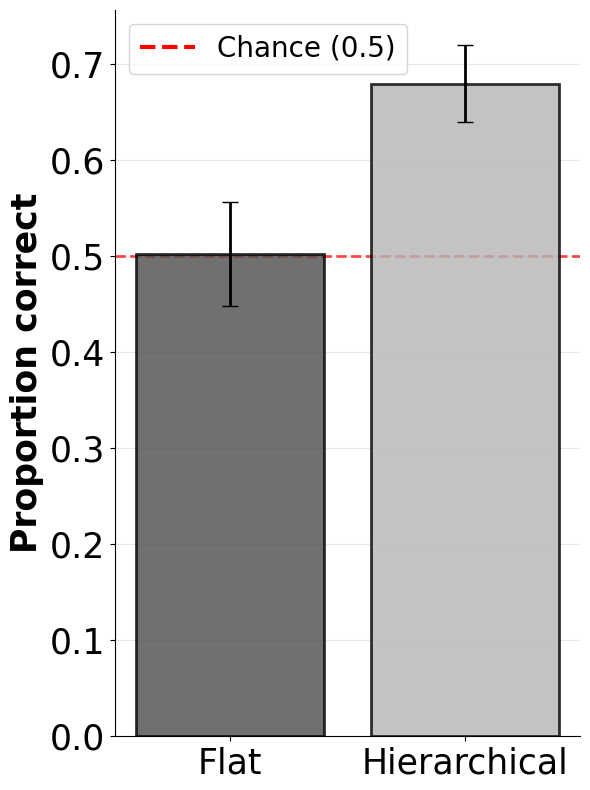

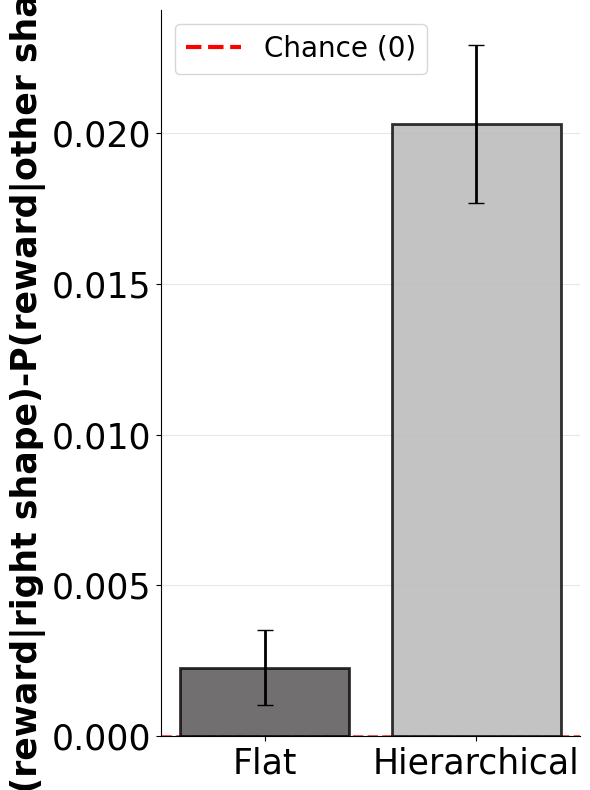

In [9]:
# ============================================================
# Shape × Many Colors Transfer Task — Analysis & Plots
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

df = pd.read_csv("shape_color_transfer_20260603_115258_all_trials.csv")

# Convenience booleans
train = df["phase"] == "train"
test  = df["phase"] == "test"
held  = df["is_first_heldout"].astype(bool)

# ── palette ──────────────────────────────────────────────────

COLOR_FLAT = "#4D4B4B"
COLOR_HIER = "#B5B5B5"
C_ADV   = "#3DAA7A"
ALPHA_ERR = 0.18

# ── bar plot helper ───────────────────────────────────────────
def create_bar_plot(data_flat, data_hier, title, ylabel, optimal_line=None,
                    line_label='Optimal', color_flat=COLOR_FLAT, color_hier=COLOR_HIER,
                    show_points=True, use_ci=True, show_ci_shade=False, ci_alpha=0.15):
    fig, ax = plt.subplots(figsize=(6, 8))

    flat_mean = np.mean(data_flat)
    hier_mean = np.mean(data_hier)
    flat_sem  = stats.sem(data_flat)
    hier_sem  = stats.sem(data_hier)

    if use_ci:
        n         = len(data_flat)
        t_crit    = stats.t.ppf(0.975, df=n - 1)
        flat_err  = t_crit * flat_sem
        hier_err  = t_crit * hier_sem
        error_type = '95% CI'
    else:
        flat_err  = flat_sem
        hier_err  = hier_sem
        error_type = 'SEM'

    if show_ci_shade:
        ax.add_patch(plt.Rectangle((-0.4, flat_mean - flat_err), 0.8, 2 * flat_err,
                                   facecolor=color_flat, alpha=ci_alpha,
                                   edgecolor='none', zorder=1))
        ax.add_patch(plt.Rectangle((0.6, hier_mean - hier_err), 0.8, 2 * hier_err,
                                   facecolor=color_hier, alpha=ci_alpha,
                                   edgecolor='none', zorder=1))

    ax.bar(['Flat', 'Hierarchical'], [flat_mean, hier_mean],
           yerr=[flat_err, hier_err],
           color=[color_flat, color_hier],
           capsize=6, edgecolor='black', linewidth=2,
           alpha=0.8, error_kw={'linewidth': 2}, zorder=5)

    if show_points:
        np.random.seed(42)
        ax.scatter(np.random.normal(0, 0.05, len(data_flat)),  data_flat,
                   color=color_flat, s=30, alpha=0.3,
                   edgecolors='white', linewidth=0.5, zorder=10)
        ax.scatter(np.random.normal(1, 0.05, len(data_hier)), data_hier,
                   color=color_hier, s=30, alpha=0.3,
                   edgecolors='white', linewidth=0.5, zorder=10)

    print(f"\nStatistics for '{title}':")
    print(f"  Flat : {flat_mean:.4f} ± {flat_err:.4f} ({error_type})")
    print(f"  Hier : {hier_mean:.4f} ± {hier_err:.4f} ({error_type})")
    print(f"  Diff : {hier_mean - flat_mean:+.4f}")
    t_stat, p_val = stats.ttest_rel(data_hier, data_flat)
    d = (hier_mean - flat_mean) / np.std(np.array(data_hier) - np.array(data_flat), ddof=1)
    print(f"  Paired t({len(data_flat)-1}) = {t_stat:+.3f}, p = {p_val:.4f}, d = {d:.3f}")

    if optimal_line is not None:
        ax.axhline(optimal_line, color='red', linestyle='--', linewidth=2,
                   alpha=0.7, label=line_label, zorder=2)

    ax.set_title('', fontsize=40, fontweight='bold', pad=40)
    ax.set_ylabel(ylabel, fontsize=25, fontweight='bold')
    ax.tick_params(axis='x', labelsize=25)
    ax.tick_params(axis='y', labelsize=25)
    ax.grid(alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    legend_elements = []
    if optimal_line is not None:
        legend_elements.append(plt.Line2D([0], [0], color='red', linestyle='--',
                                          linewidth=3, label=line_label))
    if show_ci_shade:
        legend_elements.append(plt.Rectangle((0, 0), 1, 1, fc=color_flat,
                                             alpha=ci_alpha,
                                             label=f'{error_type} (shaded)'))
    if legend_elements:
        ax.legend(handles=legend_elements, fontsize=20, loc='best')

    plt.tight_layout()
    return fig

# ── helper: 95% CI half-width ─────────────────────────────────
def ci95(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    n    = len(vals)
    if n < 2:
        return float(vals.mean()) if n == 1 else np.nan, np.nan
    se = stats.sem(vals)
    h  = se * stats.t.ppf(0.975, df=n - 1)
    return float(vals.mean()), h

# ============================================================
# 1. PER-SEED AGGREGATES
# ============================================================
seeds   = sorted(df["seed"].unique())
held_df = df[held].copy()
train_df = df[train].copy()

def brier(prob, reward):
    return float(np.mean((np.asarray(prob) - np.asarray(reward, float)) ** 2))

def logloss(prob, reward, eps=1e-9):
    p = np.clip(np.asarray(prob, float), eps, 1 - eps)
    r = np.asarray(reward, float)
    return float(np.mean(-(r * np.log(p) + (1 - r) * np.log(1 - p))))

flat_acc_seeds,  hier_acc_seeds  = [], []
flat_sc_seeds,   hier_sc_seeds   = [], []
flat_br_seeds,   hier_br_seeds   = [], []
flat_ll_seeds,   hier_ll_seeds   = [], []

for seed in seeds:
    s  = held_df[held_df["seed"] == seed]
    y  = s["reward"].values
    rs = int(s["rewarded_shape"].iloc[0])
    sg = 1 if rs == 0 else -1

    flat_acc_seeds.append(s["flat_correct"].mean())
    hier_acc_seeds.append(s["hier_correct"].mean())

    c0f = s[s["shape"] == 0]["flat_prob"].mean()
    c1f = s[s["shape"] == 1]["flat_prob"].mean()
    c0h = s[s["shape"] == 0]["hier_prob"].mean()
    c1h = s[s["shape"] == 1]["hier_prob"].mean()
    flat_sc_seeds.append(sg * (c0f - c1f))
    hier_sc_seeds.append(sg * (c0h - c1h))

    flat_br_seeds.append(brier(s["flat_prob"].values, y))
    hier_br_seeds.append(brier(s["hier_prob"].values, y))

    flat_ll_seeds.append(logloss(s["flat_prob"].values, y))
    hier_ll_seeds.append(logloss(s["hier_prob"].values, y))



# Accuracy
fig_acc = create_bar_plot(
    flat_acc_seeds, hier_acc_seeds,
    title="First-heldout accuracy",
    ylabel="Proportion correct",
    optimal_line=0.5, line_label="Chance (0.5)",
    show_points=False, use_ci=True,
)


# Signed shape contrast
fig_sc = create_bar_plot(
    flat_sc_seeds, hier_sc_seeds,
    title="Signed shape contrast (novel colors)",
    ylabel="P(reward|right shape)-P(reward|other shape)",
    color_flat=COLOR_FLAT,
    color_hier=COLOR_HIER,
    optimal_line=0.0, line_label="Chance (0)",
    show_points=False, use_ci=True,
)


# # Brier score  (lower is better — invert so "up" = better for visual consistency)
# fig_br = create_bar_plot(
#     flat_br_seeds, hier_br_seeds,
#     title="Brier score (novel colors)",
#     ylabel="Brier score  (lower = better)",
#     show_points=True, use_ci=True,
# )
# fig_br.savefig("heldout_brier.pdf", bbox_inches="tight")
# fig_br.savefig("heldout_brier.png", bbox_inches="tight", dpi=150)

# # Log loss
# fig_ll = create_bar_plot(
#     flat_ll_seeds, hier_ll_seeds,
#     title="Log loss (novel colors)",
#     ylabel="Log loss  (lower = better)",
#     show_points=True, use_ci=True,
# )
# fig_ll.savefig("heldout_logloss.pdf", bbox_inches="tight")
# fig_ll.savefig("heldout_logloss.png", bbox_inches="tight", dpi=150)

# print("\nAll figures saved.")

Loaded 600 seed rows → 30 parameter combinations
Seeds per combo: 20.0 avg
Alpha: 0.103 – 0.489
Omega: 0.050 – 0.480

All ContrastAdv > 0: True
All BrierRed > 0:    True


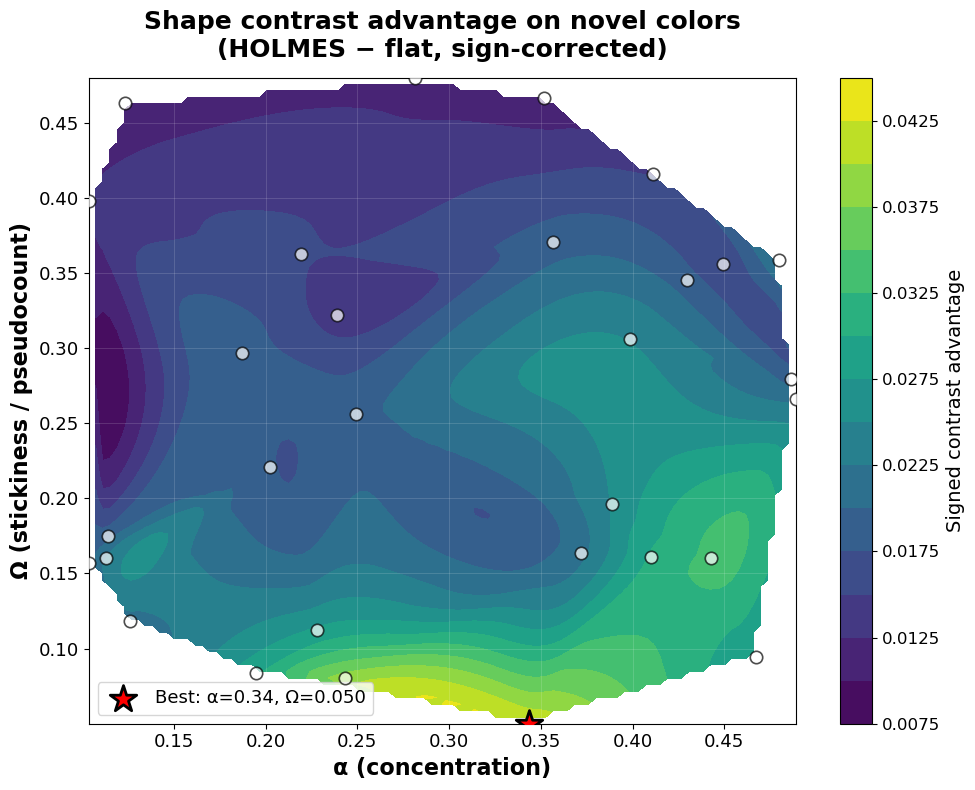

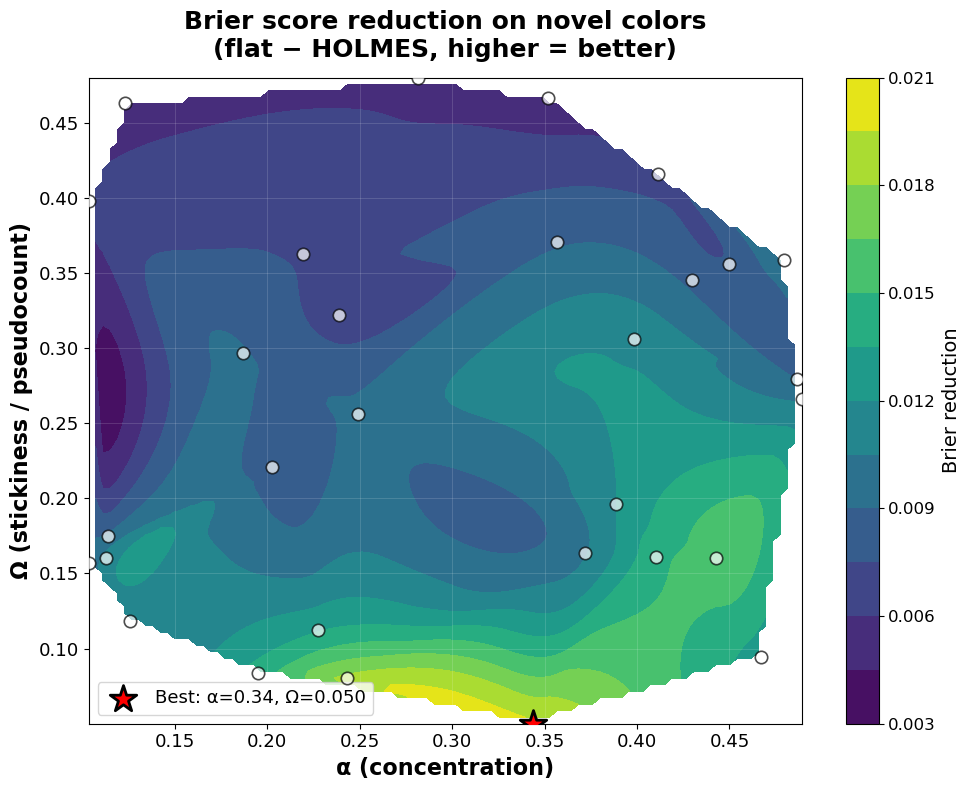

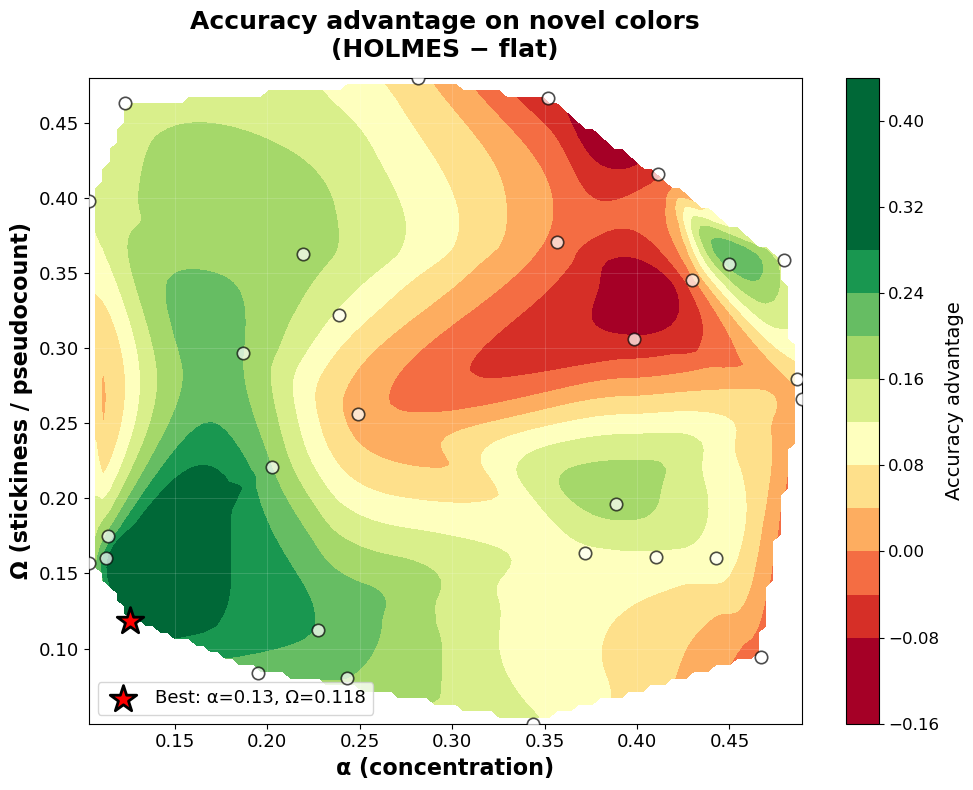

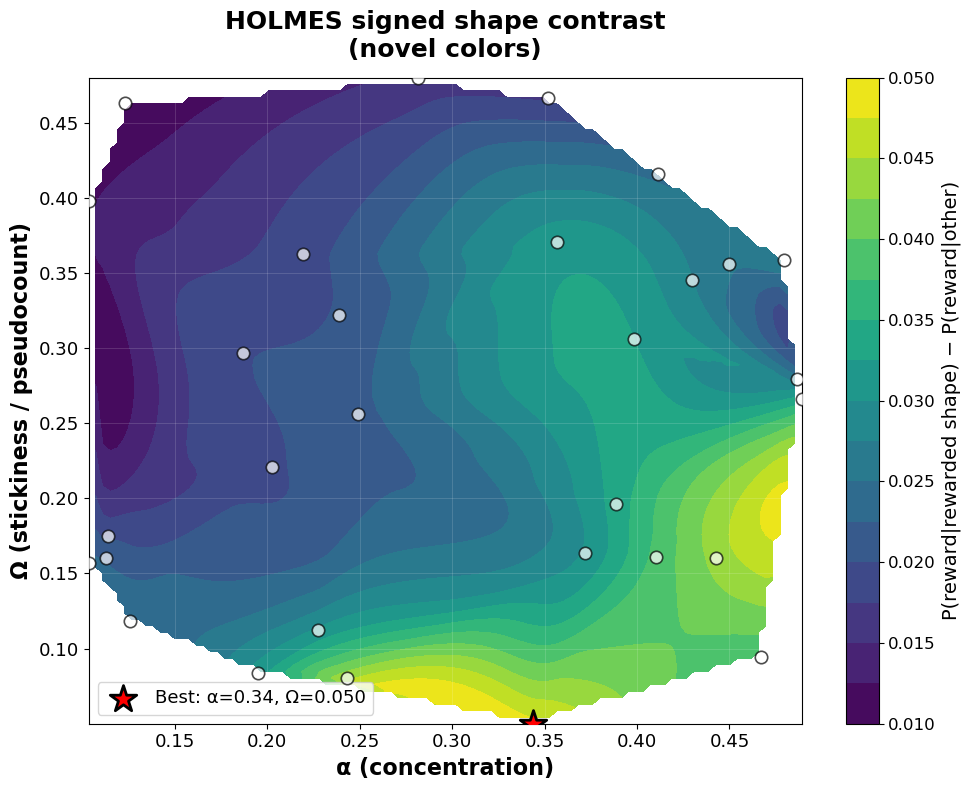

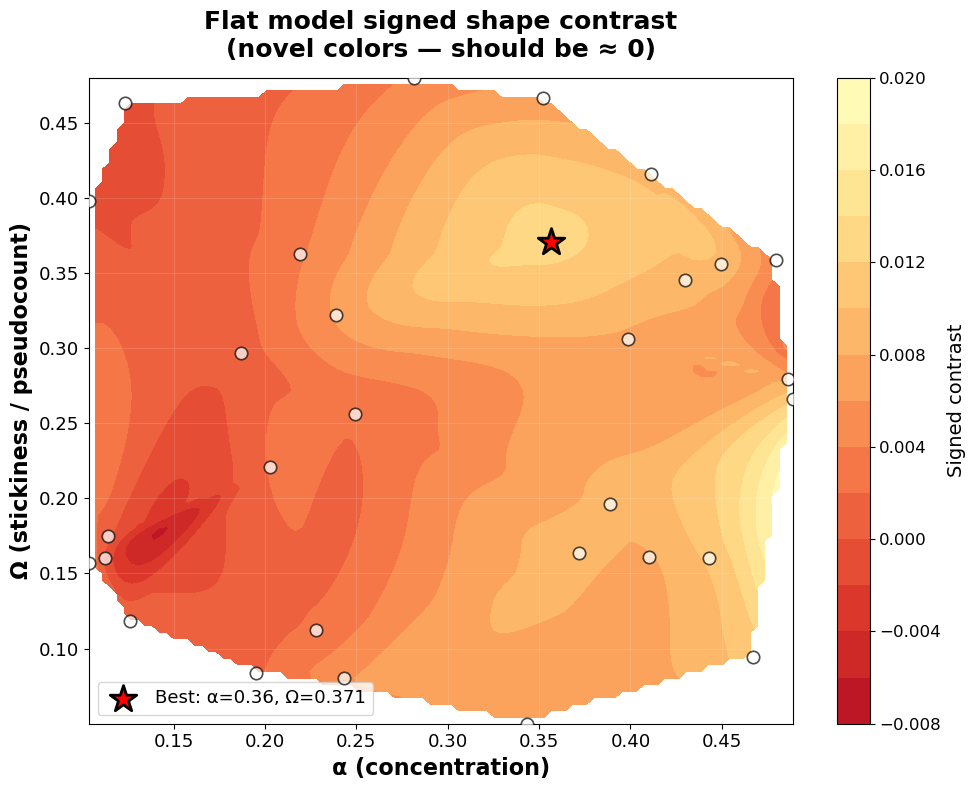

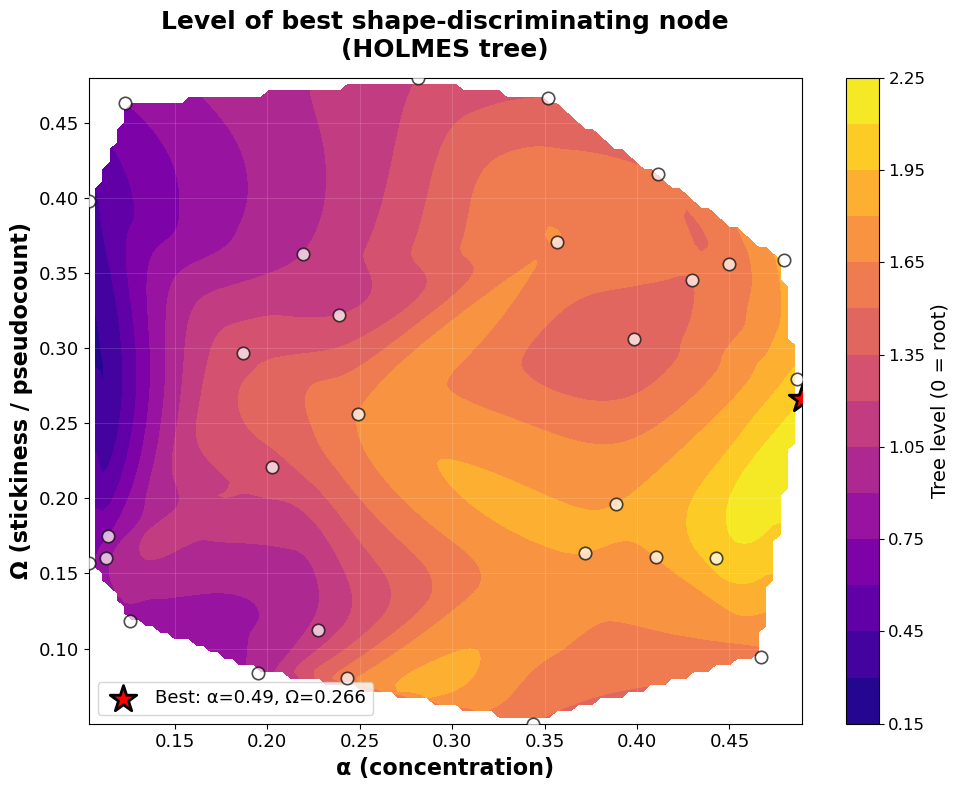

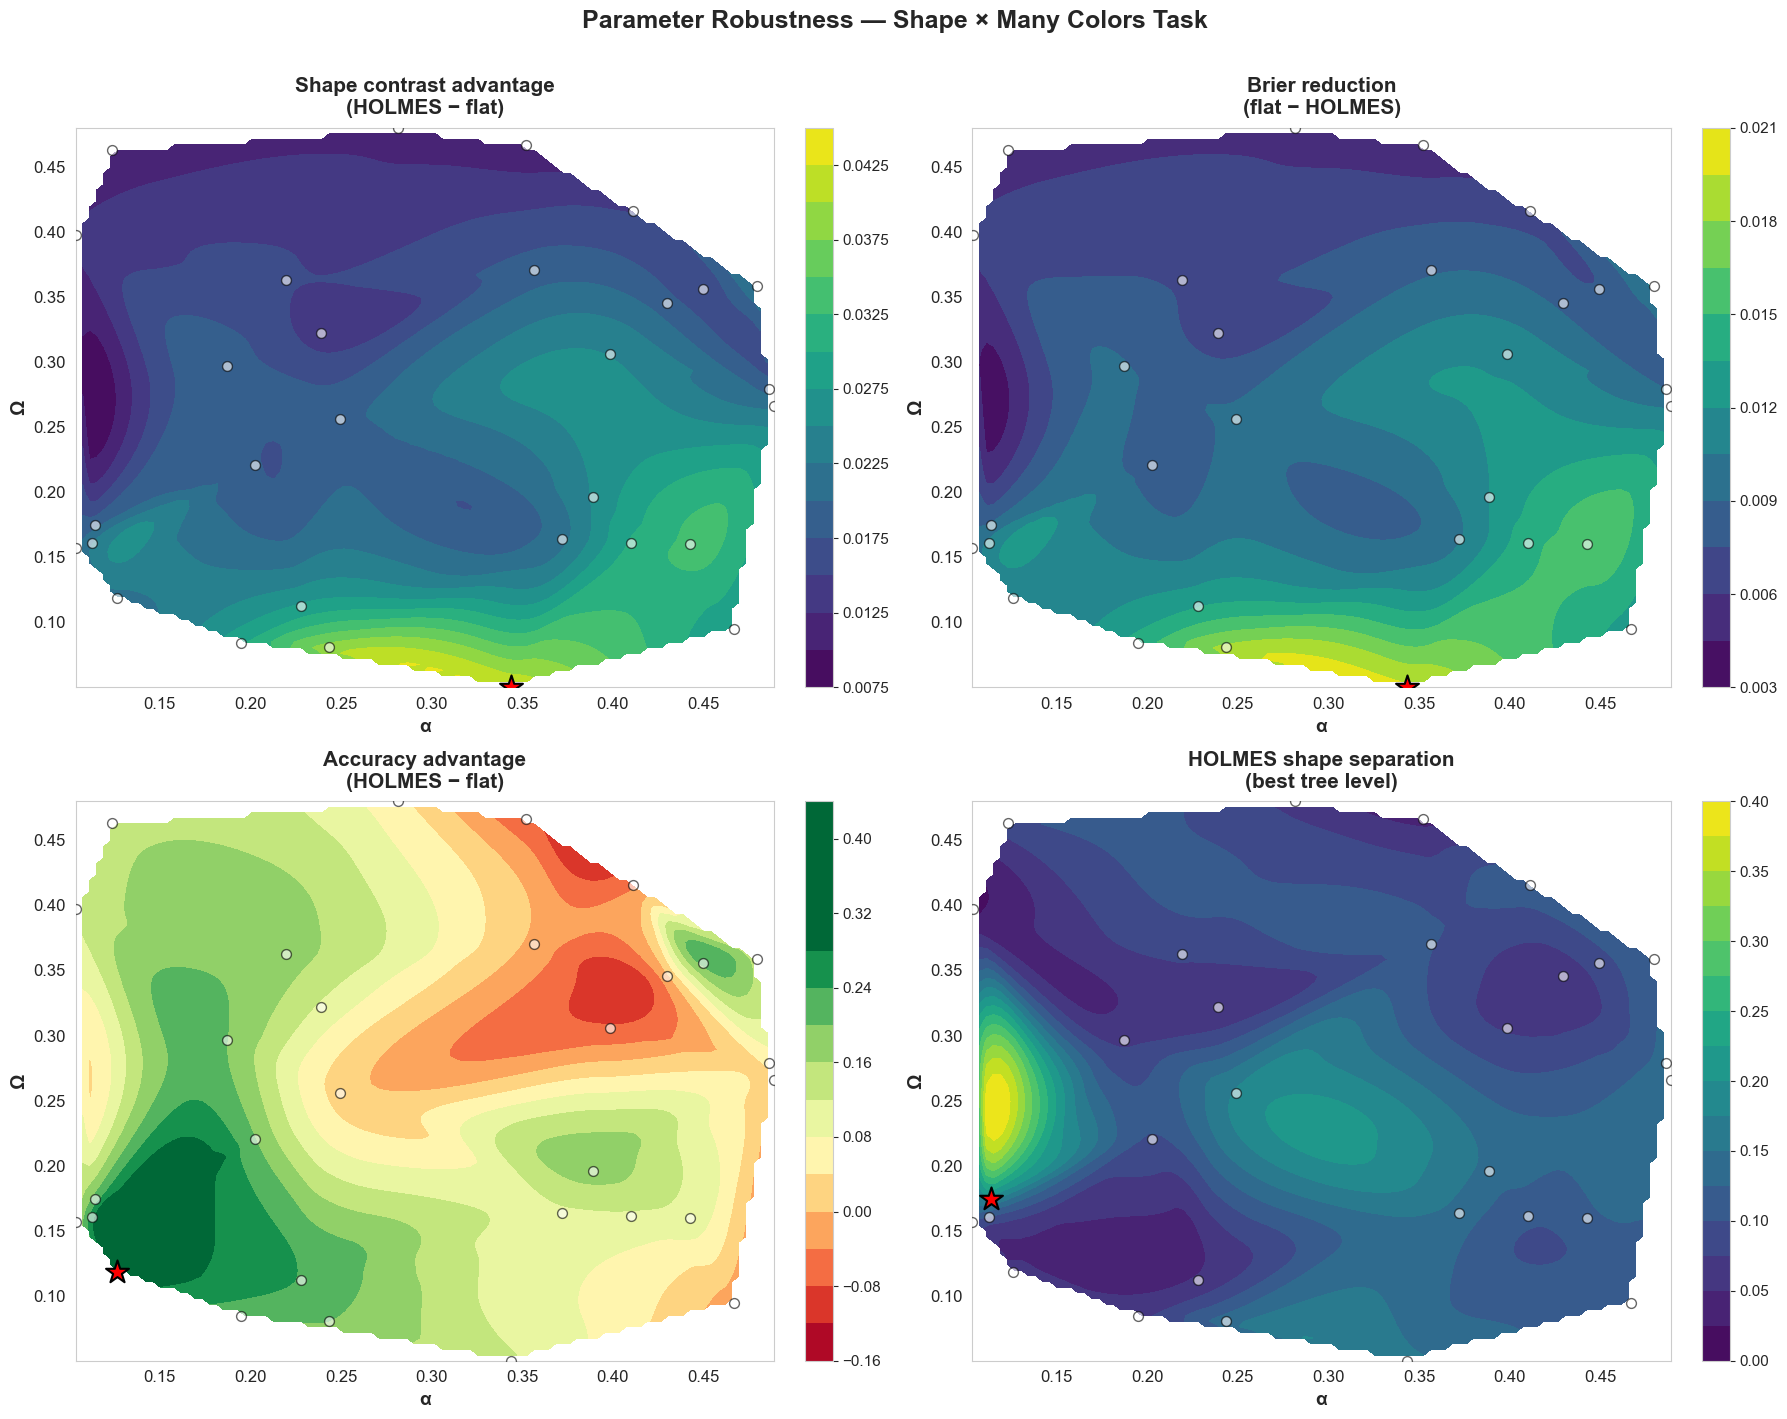

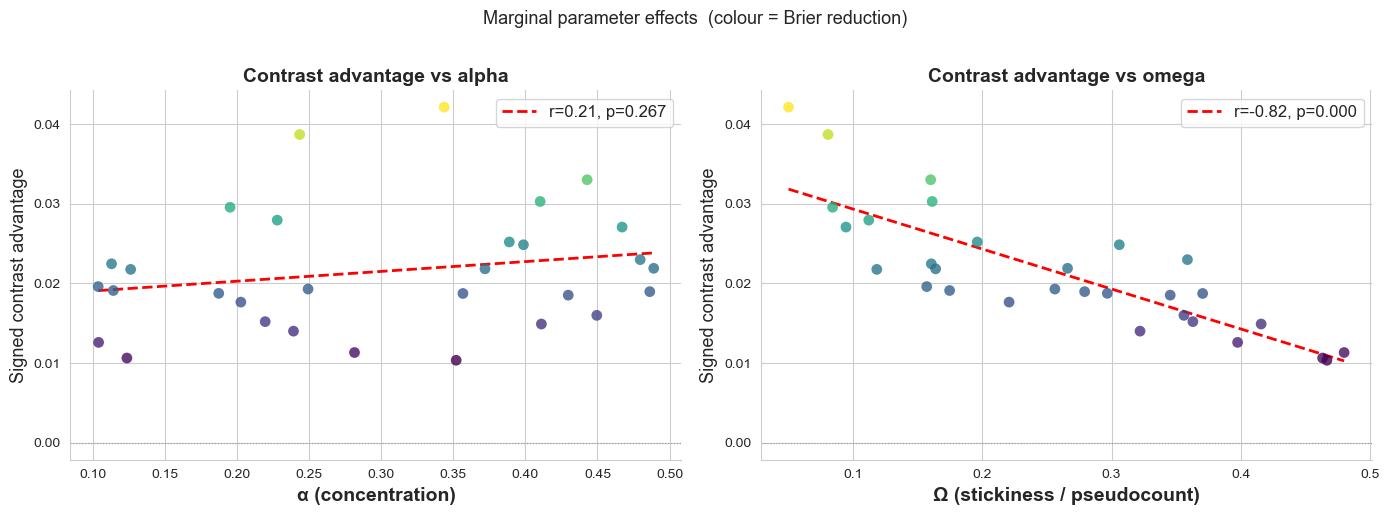


SWEEP SUMMARY

Signed contrast advantage:
  Mean ± SEM : +0.0215 ± 0.0014
  Positive   : 30/30 combinations
  t(29) = +15.180, p = 0.0000, d = 2.771

Brier reduction:
  Mean ± SEM : +0.0102 ± 0.0007
  Positive   : 30/30 combinations
  t(29) = +15.357, p = 0.0000, d = 2.804

Accuracy advantage:
  Mean ± SEM : +0.1133 ± 0.0188
  Positive   : 24/30 combinations
  t(29) = +6.032, p = 0.0000, d = 1.101


In [2]:
# ============================================================
# Shape × Many Colors Sweep — Analysis & Heatmaps
# Matches style of figures_2_3.ipynb
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.interpolate import griddata
import seaborn as sns
import os

os.makedirs('plots', exist_ok=True)

# ── load per-seed CSV ─────────────────────────────────────────
df = pd.read_csv('sweep_low_alpha_20260601_1639_per_seed.csv')

# sign-correct contrast for random_balanced
df['signed_hier_contrast'] = np.where(
    df['rewarded_shape'] == 0,
    df['hier_heldout_shape_contrast'],
   -df['hier_heldout_shape_contrast']
)
df['signed_flat_contrast'] = np.where(
    df['rewarded_shape'] == 0,
    df['flat_heldout_shape_contrast'],
   -df['flat_heldout_shape_contrast']
)
df['signed_adv_contrast'] = df['signed_hier_contrast'] - df['signed_flat_contrast']

# ── aggregate to one row per (alpha, omega) ───────────────────
agg_cols = {
    'adv_heldout_brier_reduction':  'mean',
    'adv_heldout_logloss_reduction':'mean',
    'adv_heldout_shape_contrast':   'mean',
    'signed_adv_contrast':          'mean',
    'signed_hier_contrast':         'mean',
    'signed_flat_contrast':         'mean',
    'adv_first_heldout_acc':        'mean',
    'hier_first_heldout_acc':       'mean',
    'flat_first_heldout_acc':       'mean',
    'hier_train_acc':               'mean',
    'flat_train_acc':               'mean',
    'hier_best_shape_level':        'mean',
    'hier_best_shape_separation':   'mean',
    'flat_shape_separation':        'mean',
    'hier_n_levels_used':           'mean',
    'hier_total_nodes':             'mean',
    'flat_n_clusters':              'mean',
    'hier_top_reward_node_level':   'mean',
    'hier_top_reward_node_rate':    'mean',
    'flat_color_separation':        'mean',
    'hier_color_separation_at_shape_level': 'mean',
}
sweep = df.groupby(['alpha', 'omega']).agg(
    {k: v for k, v in agg_cols.items() if k in df.columns}
).reset_index()

# also compute n_seeds per combo
sweep['n_seeds'] = df.groupby(['alpha','omega']).size().values

print(f"Loaded {len(df)} seed rows → {len(sweep)} parameter combinations")
print(f"Seeds per combo: {sweep['n_seeds'].describe()['mean']:.1f} avg")
print(f"Alpha: {sweep.alpha.min():.3f} – {sweep.alpha.max():.3f}")
print(f"Omega: {sweep.omega.min():.3f} – {sweep.omega.max():.3f}")
print(f"\nAll ContrastAdv > 0: {(sweep['signed_adv_contrast'] > 0).all()}")
print(f"All BrierRed > 0:    {(sweep['adv_heldout_brier_reduction'] > 0).all()}")

# ============================================================
# HEATMAP FUNCTION  (matches plot_parameter_heatmap style)
# ============================================================

def plot_parameter_heatmap(sweep_df, metric_col, title, cbar_label,
                            vmin=None, vmax=None, cmap='viridis',
                            multiply_100=False, mark_best=True,
                            save_path=None):
    """
    Interpolated contourf heatmap over alpha × omega space.
    Matches the style of figures_2_3.ipynb plot_parameter_heatmap.
    """
    fig, ax = plt.subplots(figsize=(10, 8))

    alpha_vals  = sweep_df['alpha'].values
    omega_vals  = sweep_df['omega'].values
    metric_vals = sweep_df[metric_col].values
    if multiply_100:
        metric_vals = metric_vals * 100

    # interpolation grid
    alpha_grid = np.linspace(alpha_vals.min(), alpha_vals.max(), 100)
    omega_grid = np.linspace(omega_vals.min(), omega_vals.max(), 100)
    alpha_mesh, omega_mesh = np.meshgrid(alpha_grid, omega_grid)

    metric_mesh = griddata(
        (alpha_vals, omega_vals),
        metric_vals,
        (alpha_mesh, omega_mesh),
        method='cubic'
    )

    # contourf
    im = ax.contourf(alpha_mesh, omega_mesh, metric_mesh,
                     levels=15, cmap=cmap,
                     vmin=vmin, vmax=vmax)
    cb = plt.colorbar(im, ax=ax, label=cbar_label)
    cb.ax.tick_params(labelsize=12)
    cb.set_label(cbar_label, fontsize=14)

    # scatter actual data points
    ax.scatter(alpha_vals, omega_vals, c='white', s=80,
               edgecolors='black', linewidth=1.2, alpha=0.7, zorder=10)

    # mark best
    if mark_best:
        best_idx = np.nanargmax(metric_vals)
        ax.scatter(alpha_vals[best_idx], omega_vals[best_idx],
                   c='red', s=400, marker='*',
                   edgecolors='black', linewidth=2,
                   label=f'Best: α={alpha_vals[best_idx]:.2f}, Ω={omega_vals[best_idx]:.3f}',
                   zorder=11)
        ax.legend(fontsize=13, frameon=True)

    ax.set_xlabel('α (concentration)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Ω (stickiness / pseudocount)', fontsize=16, fontweight='bold')
    ax.set_title(title, fontsize=18, fontweight='bold', pad=15)
    ax.tick_params(labelsize=13)
    ax.grid(alpha=0.2, color='white', linewidth=0.5)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    return fig

# ============================================================
# 1. PRIMARY RESULT HEATMAPS
# ============================================================

# 1a. Signed shape contrast advantage (primary mechanistic metric)
plot_parameter_heatmap(
    sweep, 'signed_adv_contrast',
    title='Shape contrast advantage on novel colors\n(HOLMES − flat, sign-corrected)',
    cbar_label='Signed contrast advantage',
    cmap='viridis',
    save_path='plots/heatmap_contrast_adv.png'
)

# 1b. Brier score reduction
plot_parameter_heatmap(
    sweep, 'adv_heldout_brier_reduction',
    title='Brier score reduction on novel colors\n(flat − HOLMES, higher = better)',
    cbar_label='Brier reduction',
    cmap='viridis',
    save_path='plots/heatmap_brier_red.png'
)

# 1c. First-heldout accuracy advantage
plot_parameter_heatmap(
    sweep, 'adv_first_heldout_acc',
    title='Accuracy advantage on novel colors\n(HOLMES − flat)',
    cbar_label='Accuracy advantage',
    cmap='RdYlGn', vmin=-0.1, vmax=0.3,
    save_path='plots/heatmap_acc_adv.png'
)

# ============================================================
# 2. MECHANISTIC HEATMAPS
# ============================================================

# 2a. HOLMES signed contrast (absolute, not advantage)
plot_parameter_heatmap(
    sweep, 'signed_hier_contrast',
    title='HOLMES signed shape contrast\n(novel colors)',
    cbar_label='P(reward|rewarded shape) − P(reward|other)',
    cmap='viridis',
    save_path='plots/heatmap_hier_contrast.png'
)

# 2b. Flat signed contrast (should be near zero everywhere)
plot_parameter_heatmap(
    sweep, 'signed_flat_contrast',
    title='Flat model signed shape contrast\n(novel colors — should be ≈ 0)',
    cbar_label='Signed contrast',
    cmap='RdYlGn', vmin=-0.01, vmax=0.05,
    save_path='plots/heatmap_flat_contrast.png'
)

# 2c. Best shape level in hierarchy
if 'hier_best_shape_level' in sweep.columns:
    plot_parameter_heatmap(
        sweep, 'hier_best_shape_level',
        title='Level of best shape-discriminating node\n(HOLMES tree)',
        cbar_label='Tree level (0 = root)',
        cmap='plasma',
        save_path='plots/heatmap_best_level.png'
    )

# ============================================================
# 3. COMBINED FOUR-PANEL ROBUSTNESS FIGURE
# (matches plot_parameter_robustness_combined style)
# ============================================================

def plot_robustness_combined(sweep_df, save_path=None):
    sns.set_style("whitegrid")

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    axes = axes.ravel()

    metrics = [
        ('signed_adv_contrast',           'Shape contrast advantage\n(HOLMES − flat)',
         'viridis', None,  None),
        ('adv_heldout_brier_reduction',    'Brier reduction\n(flat − HOLMES)',
         'viridis', None,  None),
        ('adv_first_heldout_acc',          'Accuracy advantage\n(HOLMES − flat)',
         'RdYlGn',  -0.15, 0.30),
        ('hier_best_shape_separation',     'HOLMES shape separation\n(best tree level)',
         'viridis', None,  None),
    ]

    for ax, (col, title, cmap, vmin, vmax) in zip(axes, metrics):
        if col not in sweep_df.columns:
            ax.set_visible(False)
            continue

        alpha_vals  = sweep_df['alpha'].values
        omega_vals  = sweep_df['omega'].values
        metric_vals = sweep_df[col].values

        alpha_grid = np.linspace(alpha_vals.min(), alpha_vals.max(), 100)
        omega_grid = np.linspace(omega_vals.min(), omega_vals.max(), 100)
        alpha_mesh, omega_mesh = np.meshgrid(alpha_grid, omega_grid)

        metric_mesh = griddata(
            (alpha_vals, omega_vals), metric_vals,
            (alpha_mesh, omega_mesh), method='cubic'
        )

        im = ax.contourf(alpha_mesh, omega_mesh, metric_mesh,
                         levels=15, cmap=cmap, vmin=vmin, vmax=vmax)
        cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cb.ax.tick_params(labelsize=11)

        ax.scatter(alpha_vals, omega_vals, c='white', s=50,
                   edgecolors='black', linewidth=1, alpha=0.6, zorder=10)

        # mark best
        best_idx = np.nanargmax(metric_vals)
        ax.scatter(alpha_vals[best_idx], omega_vals[best_idx],
                   c='red', s=300, marker='*',
                   edgecolors='black', linewidth=1.5, zorder=11)

        ax.set_xlabel('α', fontsize=14, fontweight='bold')
        ax.set_ylabel('Ω', fontsize=14, fontweight='bold')
        ax.set_title(title, fontsize=15, fontweight='bold', pad=10)
        ax.tick_params(labelsize=12)
        ax.grid(alpha=0.2, color='white')

    plt.suptitle('Parameter Robustness — Shape × Many Colors Task',
                 fontsize=18, fontweight='bold', y=1.01)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

plot_robustness_combined(sweep, save_path='plots/robustness_combined.png')

# ============================================================
# 4. MARGINAL PLOTS: effect of alpha and omega separately
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, param, label in zip(axes,
                              ['alpha', 'omega'],
                              ['α (concentration)', 'Ω (stickiness / pseudocount)']):
    ax.scatter(sweep[param], sweep['signed_adv_contrast'],
               c=sweep['adv_heldout_brier_reduction'],
               cmap='viridis', s=60, alpha=0.8,
               edgecolors='none', zorder=5)
    # regression line
    x = sweep[param].values
    y = sweep['signed_adv_contrast'].values
    mask = np.isfinite(x) & np.isfinite(y)
    slope, intercept, r, p, _ = stats.linregress(x[mask], y[mask])
    xfit = np.linspace(x.min(), x.max(), 100)
    ax.plot(xfit, slope * xfit + intercept,
            color='red', lw=2, ls='--',
            label=f'r={r:.2f}, p={p:.3f}')
    ax.axhline(0, color='#999', lw=0.8, ls=':')
    ax.set_xlabel(label, fontsize=14, fontweight='bold')
    ax.set_ylabel('Signed contrast advantage', fontsize=13)
    ax.set_title(f'Contrast advantage vs {param}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Marginal parameter effects  (colour = Brier reduction)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plots/marginal_effects.png', bbox_inches='tight', dpi=150)
plt.show()

# ============================================================
# 5. SUMMARY STATISTICS TABLE
# ============================================================

print("\n" + "="*60)
print("SWEEP SUMMARY")
print("="*60)
n = len(sweep)
for col, label in [
    ('signed_adv_contrast',        'Signed contrast advantage'),
    ('adv_heldout_brier_reduction','Brier reduction'),
    ('adv_first_heldout_acc',      'Accuracy advantage'),
]:
    if col not in sweep.columns:
        continue
    vals = sweep[col].dropna()
    t, p = stats.ttest_1samp(vals, 0)
    d    = vals.mean() / vals.std(ddof=1)
    frac = (vals > 0).sum()
    print(f"\n{label}:")
    print(f"  Mean ± SEM : {vals.mean():+.4f} ± {stats.sem(vals):.4f}")
    print(f"  Positive   : {frac}/{len(vals)} combinations")
    print(f"  t({len(vals)-1}) = {t:+.3f}, p = {p:.4f}, d = {d:.3f}")